In [2]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

sp.init_printing(use_latex='mathjax')
plt.style.use("ggplot")

print("Env setup complete.")

Env setup complete.


In [20]:
x, y = sp.symbols('x y', real=True)
f = x**2 + 3*y**2 + x*y

grad_f    = [sp.diff(f, var) for var in (x,y)]
grad_f_fn = sp.lambdify((x, y), grad_f, "numpy") 

def grad_descent(grad_fn, init, lr=0.1, steps=100):
    x, y = init
    dpts = []
    for _ in range(steps):
        gx, gy = grad_fn(x, y)
        x -= lr*gx
        y -= lr*gy
        dpts.append((x, y))
    return np.array(dpts)

path = grad_descent(grad_f_fn, init=(3.0, -1.0), steps=50)
path[45:]


array([[ 4.06988364e-04, -9.60769199e-05],
       [ 3.35198383e-04, -7.91296043e-05],
       [ 2.76071667e-04, -6.51716800e-05],
       [ 2.27374501e-04, -5.36758387e-05],
       [ 1.87267185e-04, -4.42077856e-05]])

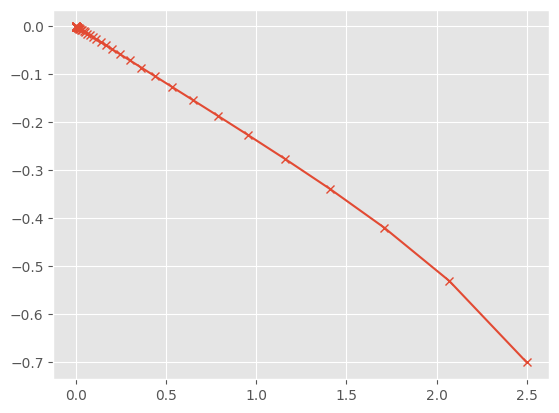

In [15]:
px, py = path[:,0], path[:,1]

plt.plot(px, py, marker='x')

(-0.001, 0.001)

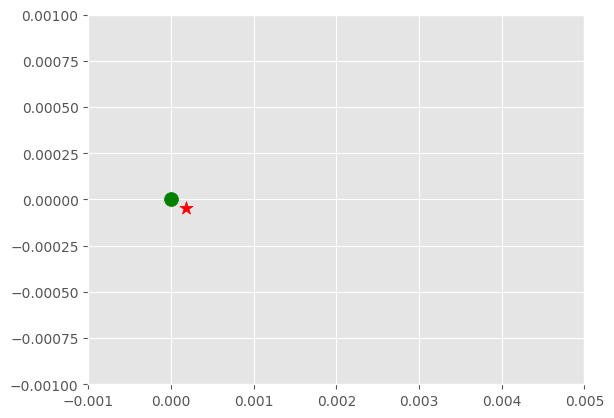

In [24]:
# plt.plot(path[:,0], path[:,1], marker='o', markersize=3)
plt.scatter(path[-1:,0], path[-1:,1], color='red', marker='*', s=100)
plt.scatter(0, 0, color='green', marker='o', s=100)
plt.xlim(-0.001, 0.005)
plt.ylim(-0.001, 0.001)

